# Choose weight, activation and accumulation precision

Runnable locally on CPU or on a Cloud TPU VM.

- Compare FP32, FP16 and BF16 rounding without confusing storage with accumulation.
- Implement per-output-channel symmetric INT8 and INT4 weight quantization.
- Calibrate activations and diagnose clipping on unseen ranges.
- Explain FP64, FP8, weight-only, full integer and mixed precision policies.

Someone asks you for an “8-bit model.” A helpful first question is: 8-bit weights, activations, or both? We’ll separate those choices, compare them with a float32 reference, and watch what happens when an input falls outside the calibrated range. You’ll leave with a precision policy you can explain, not just a dtype label.

## The idea

A precision policy specifies how weights, activations, accumulations and outputs are represented. Quantization adds scales, zero-points and rounding/clipping rules. Track those units through the computation instead of describing the whole model with one dtype label.

## Follow the units through integer arithmetic

For an illustrative scale $s=0.5$ and zero-point $z=3$, the real value $1$ maps to integer $q=5$, since $q=\operatorname{round}(1/0.5)+3$. Reconstructing gives $0.5(5-3)=1$. Real zero maps to the zero-point, not necessarily integer zero.

In a dot product, centered integer products accumulate in an appropriately wide type. The accumulator's scale comes from the input and weight scales. Bias must use compatible units before the output is rescaled or requantized.

The error plots compare specific representation policies. Read weight, activation and accumulation choices separately. Per-channel scales also require a declared axis. Numerical error, downstream quality and target-runtime speed need separate evidence.

### Integer values need scales and zero-points

**Predict:** What happens if you ignore a nonzero zero-point when interpreting quantized values?

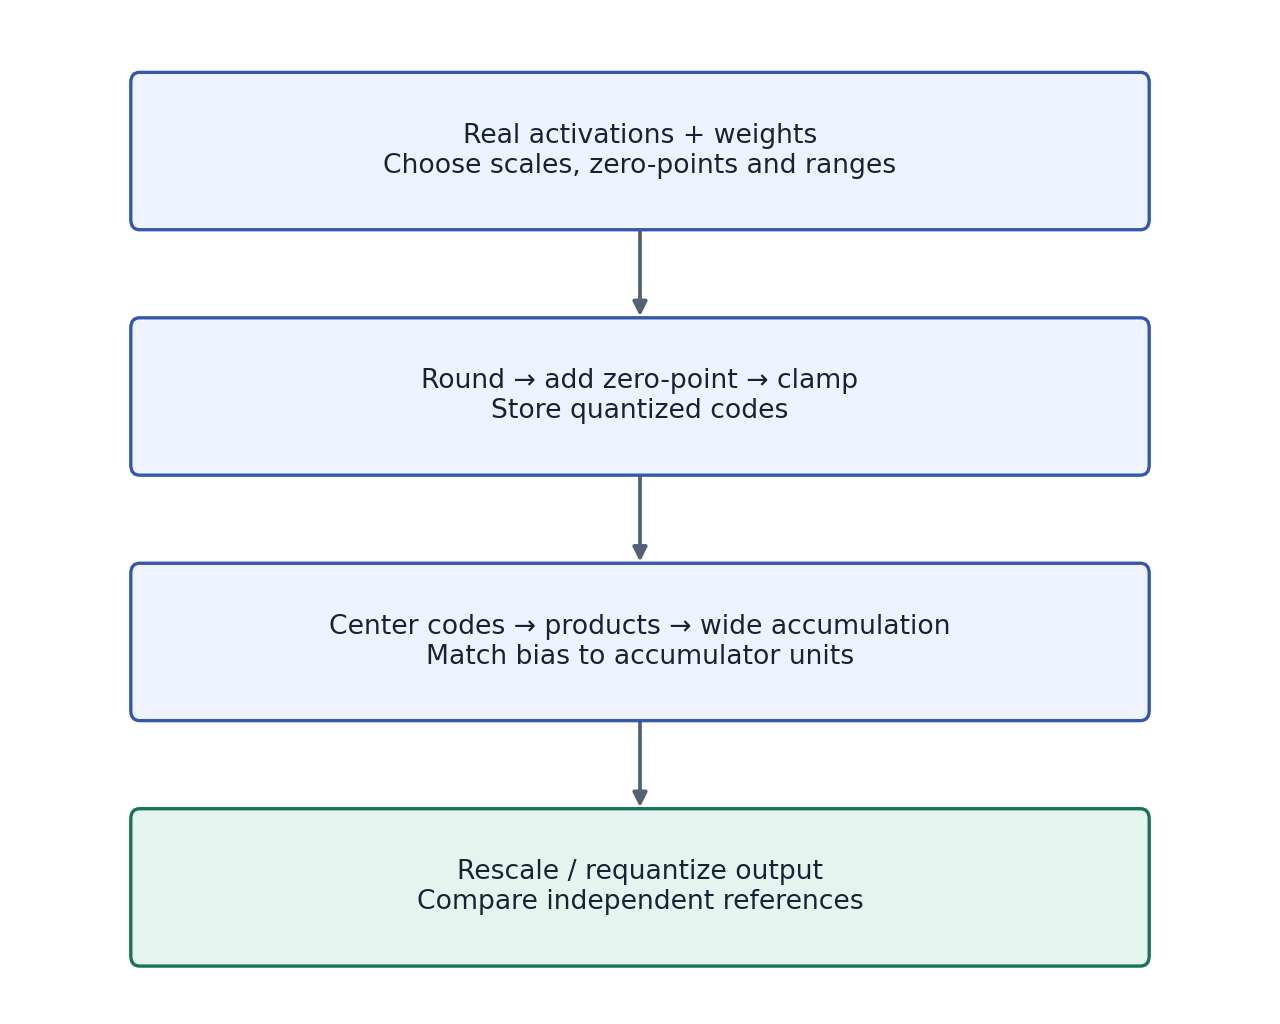

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Follow affine integer codes into centered products, wide accumulation and compatible bias units, then output rescaling. Exact accumulator dtype and per-channel scale axes belong to the declared runtime policy. These arrows describe arithmetic dependencies, not a specific hardware kernel.

### Pause and reason

What happens if you ignore a nonzero zero-point when interpreting quantized values?

<details><summary>Compare your reasoning</summary>

You introduce an offset error before multiplication or reconstruction. Correct integer storage alone is insufficient; arithmetic must honor the affine mapping.

</details>

## Write the policy before choosing a dtype

Use separate fields for stored weights, input/intermediate activations, multiply operands, accumulator, output and optimizer/master weights. FP32 is a useful baseline. FP64 can help sensitive numerical work; in JAX enable jax_enable_x64 before creating arrays and account for target support and cost. FP16 has a narrower exponent range than BF16, while BF16 gives up fraction precision for range. Keep reductions, normalization statistics and sensitive losses in FP32 when needed. The example rounds operands to each format, then explicitly returns them to FP32 for multiplication; it isolates representation error rather than proving low-precision kernel behavior.

## Mixed precision during training

A Keras mixed_float16 or mixed_bfloat16 policy generally keeps variables in FP32 while using lower-precision computations. Set the policy before constructing layers and inspect variable_dtype and compute_dtype. FP16 training may need loss scaling to avoid gradient underflow; unscale before clipping and updating, reject nonfinite updates, and keep optimizer/master state at suitable precision. BF16 has wider range but still incurs rounding. In explicit JAX code, cast intentionally at operation boundaries and test the full update. Merely changing the parameter storage dtype is not a complete mixed precision implementation.

## Quantize weights with scale metadata

Let $b$ be the number of bits and $q_{\max}=2^{b-1}-1$ the largest positive code. For each weight column, choose scale $s=\max(|w|)/q_{\max}$. Dividing a weight by $s$ moves it onto the integer grid; rounding chooses the nearest code, and clipping keeps the code in range. Reconstruct the approximate weight with $\widehat w=sq$.

Our Dense kernel’s output channels lie along axis $1$, so each column gets its own scale. This preserves resolution when columns have different ranges. For a zero column, use scale $1$ and codes $0$. Without clipping, rounding changes a value by at most $s/2$. Smaller quantization groups can improve local resolution, but each group also needs scale metadata.

## Weight-only and full integer are different deployments

W4A16 and W8A16 usually describe compressed weights with floating activations; a runtime may dequantize before multiplication or use a specialized mixed kernel. Our 4-bit codes live in int8 arrays and are not nibble-packed, so they do not realize 4-bit memory savings. W8A8 quantizes activations too. An affine activation reconstructs as $a=s(q-z)$, where $q$ is its integer code, $s$ is its scale, and $z$ is the zero point; calibration estimates its range from representative training/calibration data, never the held-out evaluation set. Static quantization fixes ranges; dynamic quantization estimates activation ranges at runtime. Accumulation commonly uses INT32 for integer kernels; bias and requantization must use compatible scales.

## FP8 and other low-bit formats require a target contract

FP8 E4M3 and E5M2 differ in range and precision; their names are not interchangeable. Scaling granularity, saturation behavior and kernel support matter. Do not treat a successful CPU dtype cast as evidence of FP8 acceleration. INT4, UINT8, INT16 activation schemes and newer sub-byte floating formats also depend on runtime/operator support. For ONNX Runtime or LiteRT, inspect the format, operator, quantization scheme and execution provider together. If a supported PTQ policy loses too much task accuracy, evaluate quantization-aware training rather than silently relaxing acceptance criteria.

## Evaluate quality separately from size and speed

Compare the original and converted models on held-out examples, including low-margin decisions and uncommon ranges. Record absolute/relative error with a sensible near-zero floor, task metrics, clipping rates and acceptance thresholds chosen in advance. Estimate weight storage as `ceil(parameter_count*bits/8)` plus metadata, but measure the real artifact and peak runtime memory. Activation buffers, KV caches, workspace and fallback copies can dominate. Benchmark on the intended device after verifying which kernels actually execute.

## Follow one value onto the quantization grid

A scale $s$ tells us how far apart the representable values are. For $s=0.1$, a weight of $0.26$ rounds to integer code $3$ and reconstructs as $0.3$. The error is $0.04$, less than half a grid step. If a value lies outside the supported range, clipping can make the error much larger. Our per-channel code computes a separate scale for each output column and treats a zero column specially.

$$
\begin{aligned}q_{\max}&=2^{b-1}-1\\q&=\operatorname{clip}\!\left(\operatorname{round}(w/s),-q_{\max},q_{\max}\right)\\\widehat w&=sq,\qquad |w-\widehat w|\le s/2\quad\text{without clipping}\end{aligned}
$$

## Follow an affine output through every numeric unit

Let an activation code be $q_x$, its zero point $z_x$, and its positive scale $s_x$. The represented value is $s_x(q_x-z_x)$. Subtract the zero point after widening the codes: raw INT8 arithmetic can overflow before accumulation. With symmetric weights, each output channel has weight zero point zero and scale $s_{w,j}$. Its accumulator therefore has units $s_xs_{w,j}$, so round the bias into those same units before adding it. In the worked experiment, corrected products plus bias give accumulators $5$ and $15$; their real outputs are $0.625$ and $0.9375$. Requantization maps these values onto the output grid. A small output scale offers fine spacing but can also make the representable range too narrow. The second plot separates forgetting the input zero point from clipping at the output; these are different bugs with different repairs.

$$
a_j=\sum_i(q_{x,i}-z_x)q_{w,ij}+\operatorname{round}\!\left(\frac{b_j}{s_xs_{w,j}}\right),\qquad q_{y,j}=\operatorname{clip}\!\left(\operatorname{round}\!\left(\frac{s_xs_{w,j}}{s_y}a_j\right)+z_y,-128,127\right)
$$

## Distinguish storage savings from an error budget

For a dense matrix with $K$ input features and $N$ output features, FP32 weights occupy $4KN$ bytes before container metadata. Ideally packed four-bit weights occupy $\lceil KN/2\rceil$ bytes, but each output channel may also need a floating-point scale. If scales are FP32, add $4N$ bytes. Biases, alignment and runtime workspace are additional terms.

For this tiny $(3,2)$ matrix, FP32 needs $24$ weight bytes. A packed four-bit representation plus two FP32 scales would need $3+8=11$ bytes before other metadata. The teaching implementation stores its codes in int8 arrays, so it uses $6+8=14$ bytes instead. Report the representation you actually measured. Neither byte count says which kernel will execute or how long a request will take.

## Follow rounding error through the next multiplication

A weight value rounded to its nearest grid point has error at most half a scale when it is within the represented range. To see why that does not directly bound the output by half a scale, write the output error as a sum of input-weight error products. Large inputs can amplify small weight errors; cancellation may reduce the observed error but should not be assumed in the bound.

For input $[2,-1,0.5]$ and weight errors $[0.1,-0.1,0.1]$, the signed output error is $0.35$. The sum of absolute products is also $0.35$, so the bound can be attained. Activation clipping is different: a value outside the represented range can lose much more than half a scale. Keep a clipping count alongside your rounding and task-quality measurements.

$$
|\Delta y_j|=\left|\sum_i x_i\Delta W_{ij}\right|\leq\sum_i |x_i|\,|\Delta W_{ij}|
$$

## Write the full-precision reference

Create main.py in your lesson workspace and run it with the active course Python environment. Keep the input and kernel in FP32 and establish an independently computed dot product.

In [1]:
# Step 1 — Write the full-precision reference: The top-left output is -1.437.
# Import numpy for this computation.
import numpy as np
import jax.numpy as jnp
# Initialize array `x` with explicit values and shape.
x = np.array([[.3, -1.2, 2.1], [1.1, .2, -.8]], np.float32)
# Initialize array `w` with explicit values and shape.
w = np.array([[.11, -1.8], [.7, .2], [-.3, 2.4]], np.float32)
# Perform matrix / vector contraction (`@`) to compute `reference`.
reference = x @ w

# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(reference[0,0], -1.437, atol=1e-6)

The top-left output is $-1.437$. This anchors the error comparison to a named value before introducing a lower-precision policy.

## Round inputs and weights, then accumulate explicitly

Append this block to the same main.py and rerun the whole file. Compare FP32, FP16 and BF16 representations while returning to FP32 before multiplication.

In [2]:
# Step 2 — Round inputs and weights, then accumulate explicitly: The printed errors isolate the consequence of representational...
def mixed_forward(x, w, dtype):
    # Demonstrate rounding inputs/weights with explicit float32 accumulation.
    a = jnp.asarray(x, dtype).astype(jnp.float32)
    # Create device-backed JAX array `b`.
    b = jnp.asarray(w, dtype).astype(jnp.float32)
    # Return `np.asarray(a @ b)` to the caller.
    return np.asarray(a @ b)
# Iterate over `dtype` to step through the computation:
for dtype in (jnp.float32, jnp.float16, jnp.bfloat16):
    # Run `mixed_forward` to compute `y`.
    y = mixed_forward(x, w, dtype)
    # Aggregate array values to compute `error`.
    error = float(np.max(np.abs(y-reference)))
    # Confirm that all computed values remain finite (no NaN or Inf).
    assert np.isfinite(y).all() and error < .05
    # Print diagnostic summary of the computed outputs.
    print(str(dtype), "max absolute error", error)

<class 'jax.numpy.float32'> max absolute error 0.0
<class 'jax.numpy.float16'> max absolute error 0.0010547637939453125
<class 'jax.numpy.bfloat16'> max absolute error 0.006171703338623047


The printed errors isolate the consequence of representational rounding in this example. This does not benchmark a native low-precision matrix kernel.

## Construct signed integer codes and channel scales

Append this block to the same main.py and rerun the whole file. Quantize per output channel and inspect the all-zero-channel case.

In [3]:
# Step 3 — Construct signed integer codes and channel scales: An all-zero channel uses scale 1 and zero codes, so reconstruction...
def quantize_weights(weights, bits):
    # Guard input contract (`bits not in (4, 8)`) and fail fast if violated.
    if bits not in (4, 8):
        raise ValueError("use signed 4 or 8 bit symmetric quantization")
    # Evaluate `limit` from the current inputs and state.
    limit = 2 ** (bits - 1) - 1
    # Reduce along axis=0 to compute `maxima`.
    maxima = np.max(np.abs(weights), axis=0, keepdims=True)
    # Cast or evaluate `scale` in explicit floating-point precision.
    scale = np.where(maxima == 0, 1., maxima / limit).astype(np.float32)
    # Combine or mask array elements to form `q`.
    q = np.clip(np.rint(weights / scale), -limit, limit).astype(np.int8)
    # Return `(q, scale)` to the caller.
    return q, scale

# Allocate initialized array `(zero_codes, zero_scales)` with the specified shape and dtype.
zero_codes, zero_scales = quantize_weights(np.zeros((3,2),np.float32), 8)
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(zero_codes, np.zeros((3,2),np.int8))
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(zero_scales, np.ones((1,2),np.float32))

An all-zero channel uses scale $1$ and zero codes, so reconstruction stays zero without division by zero.

## Check reconstructed outputs against a bound

Append this block to the same main.py and rerun the whole file. Reconstruct the weights, then compare observed output errors with the independent absolute-product bound.

In [4]:
# Step 4 — Check reconstructed outputs against a bound: Every error must fit its stated bound.
# Iterate over `bits` to step through the computation:
for bits in (8, 4):
    # Run `quantize_weights` to compute `(q, scale)`.
    q, scale = quantize_weights(w, bits)
    # Cast or evaluate `reconstructed` in explicit floating-point precision.
    reconstructed = q.astype(np.float32) * scale
    # Verify contract: `np.all(np.abs(reconstructed - w) <= scale / 2 + 1e-06)`.
    assert np.all(np.abs(reconstructed-w) <= scale / 2 + 1e-6)
    # Independent error bound: |x deltaW| <= |x| |deltaW|.
    error = np.abs(x @ reconstructed-reference)
    # Perform matrix contraction / projection to compute `bound`.
    bound = np.abs(x) @ np.broadcast_to(scale / 2, w.shape)
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert np.all(error <= bound + 1e-6)
    # Print diagnostic summary of the computed outputs.
    print("W%dA32 simulated output error" % bits, float(error.max()))

W8A32 simulated output error 0.008031368255615234
W4A32 simulated output error 0.14571428298950195


Every error must fit its stated bound. Move on to activation clipping and the affine integer experiment before calling the policy W8A8.

## Run the example

In [5]:
# Choose weight, activation and accumulation precision: A precision policy specifies how weights, activations,...
# Import numpy for this computation.
import numpy as np
import jax.numpy as jnp
# Initialize array `x` with explicit values and shape.
x = np.array([[.3, -1.2, 2.1], [1.1, .2, -.8]], np.float32)
# Initialize array `w` with explicit values and shape.
w = np.array([[.11, -1.8], [.7, .2], [-.3, 2.4]], np.float32)
# Perform matrix / vector contraction (`@`) to compute `reference`.
reference = x @ w
# Function `mixed_forward(x, w, dtype)` implementing this stage's computation:
def mixed_forward(x, w, dtype):
    # Demonstrate rounding inputs/weights with explicit float32 accumulation.
    a = jnp.asarray(x, dtype).astype(jnp.float32)
    # Create device-backed JAX array `b`.
    b = jnp.asarray(w, dtype).astype(jnp.float32)
    # Return `np.asarray(a @ b)` to the caller.
    return np.asarray(a @ b)
# Iterate over `dtype` to step through the computation:
for dtype in (jnp.float32, jnp.float16, jnp.bfloat16):
    # Run `mixed_forward` to compute `y`.
    y = mixed_forward(x, w, dtype)
    # Aggregate array values to compute `error`.
    error = float(np.max(np.abs(y-reference)))
    # Confirm that all computed values remain finite (no NaN or Inf).
    assert np.isfinite(y).all() and error < .05
    # Print diagnostic summary of the computed outputs.
    print(str(dtype), "max absolute error", error)

# Function `quantize_weights(weights, bits)` implementing this stage's computation:
def quantize_weights(weights, bits):
    # Guard input contract (`bits not in (4, 8)`) and fail fast if violated.
    if bits not in (4, 8):
        raise ValueError("use signed 4 or 8 bit symmetric quantization")
    # Evaluate `limit` from the current inputs and state.
    limit = 2 ** (bits - 1) - 1
    # Reduce along axis=0 to compute `maxima`.
    maxima = np.max(np.abs(weights), axis=0, keepdims=True)
    # Cast or evaluate `scale` in explicit floating-point precision.
    scale = np.where(maxima == 0, 1., maxima / limit).astype(np.float32)
    # Combine or mask array elements to form `q`.
    q = np.clip(np.rint(weights / scale), -limit, limit).astype(np.int8)
    # Return `(q, scale)` to the caller.
    return q, scale
# Iterate over `bits` to step through the computation:
for bits in (8, 4):
    # Run `quantize_weights` to compute `(q, scale)`.
    q, scale = quantize_weights(w, bits)
    # Cast or evaluate `reconstructed` in explicit floating-point precision.
    reconstructed = q.astype(np.float32) * scale
    # Verify contract: `np.all(np.abs(reconstructed - w) <= scale / 2 + 1e-06)`.
    assert np.all(np.abs(reconstructed-w) <= scale / 2 + 1e-6)
    # Independent error bound: |x deltaW| <= |x| |deltaW|.
    error = np.abs(x @ reconstructed-reference)
    # Perform matrix contraction / projection to compute `bound`.
    bound = np.abs(x) @ np.broadcast_to(scale / 2, w.shape)
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert np.all(error <= bound + 1e-6)
    # Print diagnostic summary of the computed outputs.
    print("W%dA32 simulated output error" % bits, float(error.max()))

<class 'jax.numpy.float32'> max absolute error 0.0
<class 'jax.numpy.float16'> max absolute error 0.0010547637939453125
<class 'jax.numpy.bfloat16'> max absolute error 0.006171703338623047
W8A32 simulated output error 0.008031368255615234
W4A32 simulated output error 0.14571428298950195


Expected: FP32, FP16 and BF16 comparisons are finite with error below $0.05$ for this fixture. INT8/INT4 reconstruction errors obey a half-scale bound; these are simulated weight-only computations.

## Precision choices trade representation for output error

Predict: Must two low-precision formats have the same error?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [6]:
# Compute figure data for: Precision choices trade representation for output error
# Evaluate `names` from the current inputs and state.
names = []
# Evaluate `errors` from the current inputs and state.
errors = []
# Loop over `(name, dtype)` in `[('FP32', jnp.float32), ('FP16 → FP32', jnp.float16), ('BF16 → FP32', jnp.bfloat16)]`:
for name, dtype in [('FP32', jnp.float32), ('FP16 → FP32', jnp.float16), ('BF16 → FP32', jnp.bfloat16)]:
    # Append the current step result to `names`.
    names.append(name)
    # Reduce across the target axis to summarize ``.
    errors.append(float(np.max(np.abs(mixed_forward(x, w, dtype) - reference))))
# Loop over `bits_plot` in `(8, 4)`:
for bits_plot in (8, 4):
    # Run `quantize_weights` to compute `(q_plot, s_plot)`.
    q_plot, s_plot = quantize_weights(w, bits_plot)
    # Append the current step result to `names`.
    names.append('W' + str(bits_plot) + ' A32')
    # Cast or evaluate `` in explicit floating-point precision.
    errors.append(float(np.max(np.abs(x @ (q_plot.astype(np.float32) * s_plot) - reference))))
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'bar', 'labels': names, 'ylabel': 'maximum absolute output error', 'series': [{'label': 'CPU reference error', 'y': errors}]}
# Deliberately exact grid values make an independent hand calculation possible.
a_sx, a_zx = .25, -3
# Convert `a_sw` to a host NumPy array for inspection or verification.
a_sw = np.array([.5, .25], np.float64)
# Convert `a_qx` to a host NumPy array for inspection or verification.
a_qx = np.array([[-3, 1, 5]], np.int8)
# Convert `a_qw` to a host NumPy array for inspection or verification.
a_qw = np.array([[2, -1], [-1, 2], [1, 1]], np.int8)
# Convert `a_bias` to a host NumPy array for inspection or verification.
a_bias = np.array([.125, -.0625], np.float64)
# Run `np.rint` to compute `a_bias_codes`.
a_bias_codes = np.rint(a_bias / (a_sx * a_sw)).astype(np.int64)
# Check the wide result before representing it with an INT32 accumulator.
a_wide = (a_qx.astype(np.int64) - a_zx) @ a_qw.astype(np.int64) + a_bias_codes
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert np.all((a_wide >= np.iinfo(np.int32).min) & (a_wide <= np.iinfo(np.int32).max))
# Run `a_wide.astype` to compute `a_acc`.
a_acc = a_wide.astype(np.int32)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_acc, [[5, 15]])
# Run `a_acc.astype` to compute `a_real`.
a_real = a_acc.astype(np.float64) * a_sx * a_sw
# Independent real-valued input/weights, written without decoding the codes.
a_reference = np.array([[0., 1., 2.]]) @ np.array([[1., -.25], [-.5, .5], [.5, .25]]) + a_bias
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_real, [[.625, .9375]])
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(a_real, a_reference, atol=1e-12, rtol=0)
# Function `output_grid(real, scale, zero_point)` implementing this stage's computation:
def output_grid(real, scale, zero_point):
    # Guard input contract (`not np.isfinite(scale) or scale <= 0`) and fail fast if violated.
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError('positive finite output scale required')
    # Guard input contract (`type(zero_point) is not int or not -128 <= zero_point <= 127`) and fail fast if violated.
    if type(zero_point) is not int or not -128 <= zero_point <= 127:
        raise ValueError('integer INT8 zero point required')
    # Run `np.rint` to compute `unbounded`.
    unbounded = np.rint(real / scale) + zero_point
    # Evaluate `clipped` from the current inputs and state.
    clipped = (unbounded < -128) | (unbounded > 127)
    # Combine or mask array elements to form `codes`.
    codes = np.clip(unbounded, -128, 127).astype(np.int8)
    # Return `(codes, (codes.astype(np.float64) - zero_point) * scale, clipped)` to the caller.
    return codes, (codes.astype(np.float64) - zero_point) * scale, clipped

# Run `output_grid` to compute `(a_codes, a_restored, a_clipped)`.
a_codes, a_restored, a_clipped = output_grid(a_real, .0625, -8)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_codes, [[2, 7]])
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not a_clipped.any()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(a_restored, a_reference, atol=1e-12, rtol=0)
# Perform matrix contraction / projection to compute `a_wrong`.
a_wrong = (a_qx.astype(np.int64) @ a_qw.astype(np.int64) + a_bias_codes) * a_sx * a_sw
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_wrong, [[-.125, .5625]])
# Run `output_grid` to compute `(_, a_saturated, a_small_clipped)`.
_, a_saturated, a_small_clipped = output_grid(a_real, 1./256, -8)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert a_small_clipped.all()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_saturated, [[135./256, 135./256]])
# Print diagnostic summary of the computed outputs.
print('Affine accumulators:', a_acc.tolist(), 'output codes:', a_codes.tolist())
# Print diagnostic summary of the computed outputs.
print('Correct / missing zero point / clipped:', a_restored.tolist(), a_wrong.tolist(), a_saturated.tolist())

# Evaluate `first_panel` from the current inputs and state.
first_panel = visual_data
# Combine or mask array elements to form `visual_data`.
visual_data = {'panels': [first_panel, {'kind': 'bar', 'labels': ['output 0', 'output 1'], 'ylabel': 'output value', 'series': [
    {'label': 'correct affine / float reference', 'y': a_restored[0].tolist()},
    {'label': 'input zero point omitted', 'y': a_wrong[0].tolist()},
    {'label': 'narrow output grid clips', 'y': a_saturated[0].tolist()}]}]}

Affine accumulators: [[5, 15]] output codes: [[2, 7]]
Correct / missing zero point / clipped: [[0.625, 0.9375]] [[-0.125, 0.5625]] [[0.52734375, 0.52734375]]


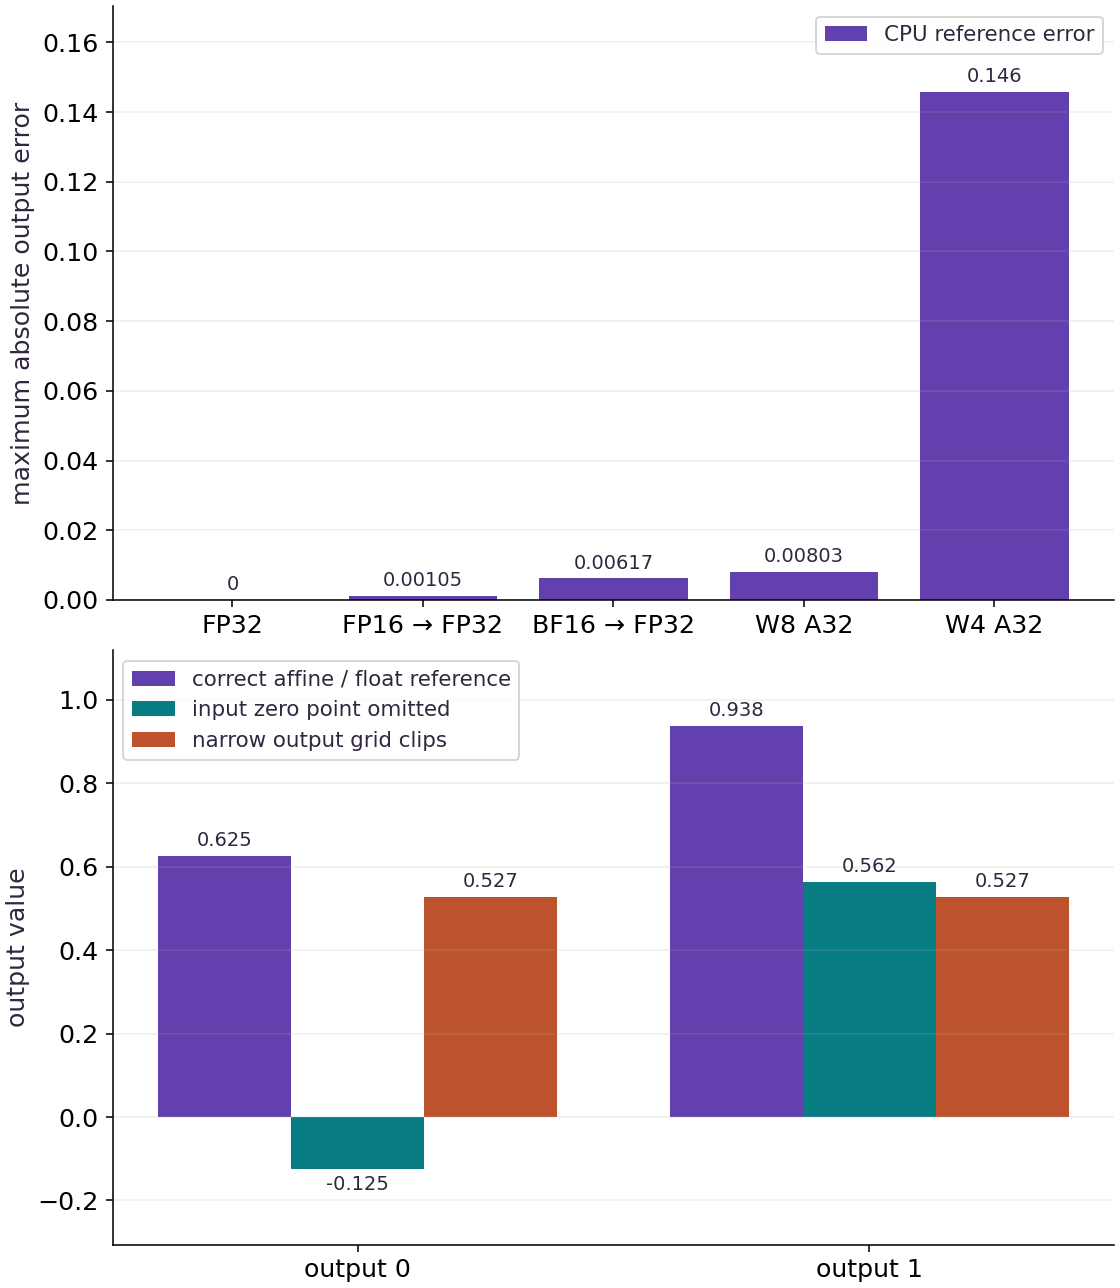

In [7]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories are precision policies; the vertical axis is maximum absolute output error against the FP32 reference on the same small input. Lower bars mean closer numerical agreement, not faster execution. The FP32 baseline is zero by construction.

The errors are approximately $0.00105$ for FP16 rounding, $0.00617$ for BF16 rounding, $0.00803$ for W8 A32, and $0.146$ for W4 A32. The four-bit weight simulation has about eighteen times the output error of the eight-bit simulation in this example. These are output units, not percentages or classification error rates.

The lower panel uses a separate exactly representable affine fixture, with output channel on the horizontal axis and real output value on the vertical axis. Correct values are $0.625$ and $0.9375$. Omitting the input zero point lowers them to $-0.125$ and $0.5625$; this is systematic offset error, not random rounding. The narrow output grid makes both bars equal $0.52734375$, the largest representable output under that policy. Equal bars here reveal saturation, not equal underlying predictions.

### Connect it to the computation

For the floating-point policies, both inputs and weights are rounded, then converted to FP32 for accumulation. FP16 has finer precision than BF16 around these particular values; BF16’s wider exponent range is not being tested here. The weight-only policies keep activations in FP32 and reconstruct quantized weights before multiplication.

Four-bit quantization uses fewer representable weight levels, so its larger rounding steps can create larger output discrepancies. The code uses per-output-column scales and checks an independent error bound. This is simulated quantization using ordinary CPU arrays, not a measurement of packed four-bit storage or native low-bit kernels. Accuracy, memory, and latency must each be evaluated on the intended workload and runtime.

Use the lower panel to decide what to inspect: zero-point subtraction and bias units for an offset mismatch; output range and clipping counts for saturation. The upper panel compares precision policies on the original fixture, while the lower panel isolates operator bookkeeping on a different fixture. Neither measures latency.

## Calibrate an activation range, then shift it

Predict: What happens to a value of $4$ if calibration only covered $[-1, 1]$?

In [8]:
# Experiment — Calibrate an activation range, then shift it: Do not recalibrate on the test set to hide this error.
# Initialize array `calibration` with explicit values and shape.
calibration = np.linspace(-1., 1., 101, dtype=np.float32)
# Aggregate array values to compute `activation_scale`.
activation_scale = float(np.max(np.abs(calibration))) / 127
# Initialize array `held_out` with explicit values and shape.
held_out = np.array([.2, .9, 4.], np.float32)
# Combine or mask array elements to form `activation_codes`.
activation_codes = np.clip(np.rint(held_out / activation_scale), -127, 127).astype(np.int8)
# Cast or evaluate `restored_activations` in explicit floating-point precision.
restored_activations = activation_codes.astype(np.float32) * activation_scale
# Run `np.count_nonzero` to compute `clipped`.
clipped = np.count_nonzero(np.abs(held_out) > 127 * activation_scale)
# Verify contract: `clipped == 1 and abs(float(restored_activations[-1]) - 4.0) > 2.9`.
assert clipped == 1 and abs(float(restored_activations[-1])-4.) > 2.9
# Print the observed values to compare against the expected result.
print("Clipped values:", clipped, "reconstructed:", restored_activations)

Clipped values: 1 reconstructed: [0.19685039 0.8976378  1.        ]


Expected: One value clips and reconstructs near $1$ instead of $4$.

Do not recalibrate on the test set to hide this error. Collect representative calibration data or choose a policy that meets the task requirements.

## Include zero points, bias and the output grid

Predict: Can finer output spacing make the answer worse? Predict the two outputs when the output scale changes from $0.0625$ to $1/256$, with zero point $-8$ held fixed.

In [9]:
# Deliberately exact grid values make an independent hand calculation possible.
a_sx, a_zx = .25, -3
# Initialize array `a_sw` with explicit values and shape.
a_sw = np.array([.5, .25], np.float64)
# Initialize array `a_qx` with explicit values and shape.
a_qx = np.array([[-3, 1, 5]], np.int8)
# Initialize array `a_qw` with explicit values and shape.
a_qw = np.array([[2, -1], [-1, 2], [1, 1]], np.int8)
# Initialize array `a_bias` with explicit values and shape.
a_bias = np.array([.125, -.0625], np.float64)
# Run `np.rint` to compute `a_bias_codes`.
a_bias_codes = np.rint(a_bias / (a_sx * a_sw)).astype(np.int64)
# Check the wide result before representing it with an INT32 accumulator.
a_wide = (a_qx.astype(np.int64) - a_zx) @ a_qw.astype(np.int64) + a_bias_codes
# Verify contract: `np.all((a_wide >= np.iinfo(np.int32).min) & (a_wide <= np.iinfo(np.i...`.
assert np.all((a_wide >= np.iinfo(np.int32).min) & (a_wide <= np.iinfo(np.int32).max))
# Run `a_wide.astype` to compute `a_acc`.
a_acc = a_wide.astype(np.int32)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_acc, [[5, 15]])
# Run `a_acc.astype` to compute `a_real`.
a_real = a_acc.astype(np.float64) * a_sx * a_sw
# Independent real-valued input/weights, written without decoding the codes.
a_reference = np.array([[0., 1., 2.]]) @ np.array([[1., -.25], [-.5, .5], [.5, .25]]) + a_bias
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_real, [[.625, .9375]])
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(a_real, a_reference, atol=1e-12, rtol=0)
# Function `output_grid(real, scale, zero_point)` implementing this stage's computation:
def output_grid(real, scale, zero_point):
    # Guard input contract (`not np.isfinite(scale) or scale <= 0`) and fail fast if violated.
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError('positive finite output scale required')
    # Guard input contract (`type(zero_point) is not int or not -128 <= zero_point <= 127`) and fail fast if violated.
    if type(zero_point) is not int or not -128 <= zero_point <= 127:
        raise ValueError('integer INT8 zero point required')
    # Run `np.rint` to compute `unbounded`.
    unbounded = np.rint(real / scale) + zero_point
    # Evaluate `clipped` from the current inputs and state.
    clipped = (unbounded < -128) | (unbounded > 127)
    # Combine or mask array elements to form `codes`.
    codes = np.clip(unbounded, -128, 127).astype(np.int8)
    # Return `(codes, (codes.astype(np.float64) - zero_point) * scale, clipped)` to the caller.
    return codes, (codes.astype(np.float64) - zero_point) * scale, clipped

# Run `output_grid` to compute `(a_codes, a_restored, a_clipped)`.
a_codes, a_restored, a_clipped = output_grid(a_real, .0625, -8)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_codes, [[2, 7]])
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not a_clipped.any()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(a_restored, a_reference, atol=1e-12, rtol=0)
# Perform matrix contraction / projection to compute `a_wrong`.
a_wrong = (a_qx.astype(np.int64) @ a_qw.astype(np.int64) + a_bias_codes) * a_sx * a_sw
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_wrong, [[-.125, .5625]])
# Run `output_grid` to compute `(_, a_saturated, a_small_clipped)`.
_, a_saturated, a_small_clipped = output_grid(a_real, 1./256, -8)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert a_small_clipped.all()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(a_saturated, [[135./256, 135./256]])
# Print diagnostic summary of the computed outputs.
print('Affine accumulators:', a_acc.tolist(), 'output codes:', a_codes.tolist())
# Print diagnostic summary of the computed outputs.
print('Correct / missing zero point / clipped:', a_restored.tolist(), a_wrong.tolist(), a_saturated.tolist())

Affine accumulators: [[5, 15]] output codes: [[2, 7]]
Correct / missing zero point / clipped: [[0.625, 0.9375]] [[-0.125, 0.5625]] [[0.52734375, 0.52734375]]


Expected: Accumulators [[5, 15]], output codes [[2, 7]], correct outputs [[0.625, 0.9375]]. Omitting the input zero point gives [[-0.125, 0.5625]]. The narrow output grid clips both outputs to [[0.52734375, 0.52734375]].

The first grid represents both values exactly. With scale $1/256$, the highest output is $(127+8)/256=0.52734375$, so both values saturate. A half-step rounding bound applies only without clipping. This is a NumPy arithmetic audit, not a native INT8 kernel or bit-exact LiteRT implementation: real runtimes specify operator layouts, multiplier approximations and rounding rules separately.

## Give small and large output channels different grids

Predict: If one output channel has weights near $0.01$ and another near $10$, what happens to the small channel under one shared INT8 scale?

In [10]:
# Experiment — Give small and large output channels different grids: The global maximum determines a coarse grid for every channel.
# Initialize array `heterogeneous` with explicit values and shape.
heterogeneous = np.array([[.01, 10.], [-.02, -5.], [.03, 2.]], np.float32)
# Run `quantize_weights` to compute `(channel_codes, channel_scales)`.
channel_codes, channel_scales = quantize_weights(heterogeneous, 8)
# Cast or evaluate `per_channel` in explicit floating-point precision.
per_channel = channel_codes.astype(np.float32) * channel_scales
# Aggregate array values to compute `shared_scale`.
shared_scale = np.max(np.abs(heterogeneous)) / 127
# Cast or evaluate `shared` in explicit floating-point precision.
shared = np.clip(np.rint(heterogeneous/shared_scale), -127, 127).astype(np.int8).astype(np.float32)*shared_scale
# Verify contract: `np.all(shared[:, 0] == 0)`.
assert np.all(shared[:,0] == 0)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert np.max(np.abs(per_channel[:,0]-heterogeneous[:,0])) < .001
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(shared[:,0], [0.,0.,0.], atol=0)
# Print the observed values to compare against the expected result.
print('Small-channel max error; shared / per-channel:', np.max(np.abs(shared[:,0]-heterogeneous[:,0])), np.max(np.abs(per_channel[:,0]-heterogeneous[:,0])))

Small-channel max error; shared / per-channel: 0.03 7.874053e-05


Expected: The shared scale rounds the entire small channel to zero. Its error is $0.03$; the per-channel error stays below $0.001$.

The global maximum determines a coarse grid for every channel. A per-channel grid protects the small channel here, at the cost of additional scale metadata and a runtime contract that must support the chosen axis.

## Your exercise

Add a zero-valued output channel and verify that its quantization scale is finite and its reconstruction is exactly zero.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.isfinite(x)` — Returns a boolean mask verifying that no element is `NaN` or `Inf`.

**Step-by-step implementation plan:**
1. Run `quantize_weights` to compute `(q, scale)`.
2. Confirm that all computed values remain finite (no NaN or Inf).
3. Verify that computed values match the expected reference within numerical tolerance.
4. Verify that computed values match the expected reference within numerical tolerance.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Add a zero-valued output channel and verify that its quantization...
with_zero = np.column_stack(...)  # TODO: compute with_zero
# Run `quantize_weights` to compute `(q, scale)`.
q, scale = quantize_weights(...)  # TODO: compute q, scale
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(scale).all()  # TODO: complete assertion check
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(q[:, -1], 0)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal((q * scale)[:, -1], 0)
# Print the observed values to compare against the expected result.
print("Zero channel handled")
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Add a zero-valued output channel and verify that its quantization...
# with_zero = np.column_stack(...)  # TODO: compute with_zero
# Run `quantize_weights` to compute `(q, scale)`.
# q, scale = quantize_weights(...)  # TODO: compute q, scale
# Confirm that all computed values remain finite (no NaN or Inf).
# assert np.isfinite(scale).all()  # TODO: complete assertion check
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal(q[:, -1], 0)
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal((q * scale)[:, -1], 0)
# Print the observed values to compare against the expected result.
# print("Zero channel handled")

## Reference solution

Try your own implementation first.

In [12]:
# Exercise solution: Add a zero-valued output channel and verify that its quantization...
with_zero = np.column_stack((w, np.zeros(3, np.float32)))
# Run `quantize_weights` to compute `(q, scale)`.
q, scale = quantize_weights(with_zero, 8)
# Confirm that all computed values remain finite (no NaN or Inf).
assert np.isfinite(scale).all()
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(q[:, -1], 0)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal((q * scale)[:, -1], 0)
# Print the observed values to compare against the expected result.
print("Zero channel handled")

Zero channel handled


## Compute W8A8 with a wide accumulator · Transfer

Use calibrated symmetric scales for $x$ and per-channel scales for $w$. Multiply integer codes with INT32 accumulation, rescale, and compare to the float baseline. Do not multiply int8 arrays directly.

Hint: Cast both integer-code arrays before multiplication. The real accumulator unit is the activation scale multiplied by each output channel’s weight scale; compare with the unchanged floating-point reference.

### How to write: Compute W8A8 with a wide accumulator — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Aggregate array values to compute `sx`.
2. Combine or mask array elements to form `qx`.
3. Run `quantize_weights` to compute `(qw, sw)`.
4. Perform matrix / vector contraction (`@`) to compute `accumulator`.
5. Cast or evaluate `y_integer` in explicit floating-point precision.

**Starter code scaffold (fill in the TODOs):**

```python
# Compute W8A8 with a wide accumulator (Transfer): This dense fixture uses zero points of zero and no bias.
# Aggregate array values to compute `sx`.
sx = float(...)  # TODO: compute sx
# Combine or mask array elements to form `qx`.
qx = np.clip(...)  # TODO: compute qx
# Run `quantize_weights` to compute `(qw, sw)`.
qw, sw = quantize_weights(...)  # TODO: compute qw, sw
# Perform matrix / vector contraction (`@`) to compute `accumulator`.
accumulator = qx.astype(...)  # TODO: compute accumulator
# Cast or evaluate `y_integer` in explicit floating-point precision.
y_integer = accumulator.astype(...)  # TODO: compute y_integer
# Verify contract: `accumulator.dtype == np.int32`.
assert accumulator.dtype  # TODO: complete assertion check
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(y_integer, reference, atol = ...  # TODO: compute np.testing.assert_allclose(y_integer, reference, atol
# Print the observed values to compare against the expected result.
print("W8A8 fixture error", float(np.max(np.abs(y_integer-reference))))
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Compute W8A8 with a wide accumulator (Transfer): This dense fixture uses zero points of zero and no bias.
# Aggregate array values to compute `sx`.
# sx = float(...)  # TODO: compute sx
# Combine or mask array elements to form `qx`.
# qx = np.clip(...)  # TODO: compute qx
# Run `quantize_weights` to compute `(qw, sw)`.
# qw, sw = quantize_weights(...)  # TODO: compute qw, sw
# Perform matrix / vector contraction (`@`) to compute `accumulator`.
# accumulator = qx.astype(...)  # TODO: compute accumulator
# Cast or evaluate `y_integer` in explicit floating-point precision.
# y_integer = accumulator.astype(...)  # TODO: compute y_integer
# Verify contract: `accumulator.dtype == np.int32`.
# assert accumulator.dtype  # TODO: complete assertion check
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(y_integer, reference, atol = ...  # TODO: compute np.testing.assert_allclose(y_integer, reference, atol
# Print the observed values to compare against the expected result.
# print("W8A8 fixture error", float(np.max(np.abs(y_integer-reference))))

## Reference reasoning

This dense fixture uses zero points of zero and no bias. A real affine operator must subtract zero points and handle bias and output requantization. Wide accumulation avoids int8 overflow; sufficiently long reductions can still overflow INT32.

In [14]:
# Compute W8A8 with a wide accumulator (Transfer): This dense fixture uses zero points of zero and no bias.
# Aggregate array values to compute `sx`.
sx = float(np.max(np.abs(x))) / 127
# Combine or mask array elements to form `qx`.
qx = np.clip(np.rint(x / sx), -127, 127).astype(np.int8)
# Run `quantize_weights` to compute `(qw, sw)`.
qw, sw = quantize_weights(w, 8)
# Perform matrix / vector contraction (`@`) to compute `accumulator`.
accumulator = qx.astype(np.int32) @ qw.astype(np.int32)
# Cast or evaluate `y_integer` in explicit floating-point precision.
y_integer = accumulator.astype(np.float32) * sx * sw
# Verify contract: `accumulator.dtype == np.int32`.
assert accumulator.dtype == np.int32
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(y_integer, reference, atol=.06, rtol=0)
# Print the observed values to compare against the expected result.
print("W8A8 fixture error", float(np.max(np.abs(y_integer-reference))))

W8A8 fixture error 0.00742650032043457


## Change the code origin without changing the values · Transfer

Change the activation zero point from $-3$ to $17$, shift the input codes accordingly, and prove that predictions stay unchanged. Then feed codes representing real zero and identify the expected bias-only result.

Hint: Shift the zero point and codes by the same amount before subtracting; verify representability before casting back to INT8.

### How to write: Change the code origin without changing the values — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `values(...)` — Call `values` with your updated parameters or inputs from this lesson's workspace.
- `a_qx.astype(...)` — Call `a_qx.astype` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run `a_qx.astype` to compute `shifted_codes_wide`.
2. Verify contract: `np.all((-128 <= shifted_codes_wide) & (shifted_codes_wide <= 127))`.
3. Run `shifted_codes_wide.astype` to compute `shifted_codes`.
4. Perform matrix contraction / projection to compute `shifted_acc`.
5. Verify that computed values match the expected reference within numerical tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Change the code origin without changing the values (Transfer): Integer codes are coordinates on a grid.
shifted_zx = ...  # TODO: compute shifted_zx
# Run `a_qx.astype` to compute `shifted_codes_wide`.
shifted_codes_wide = a_qx.astype(...)  # TODO: compute shifted_codes_wide
# Verify contract: `np.all((-128 <= shifted_codes_wide) & (shifted_codes_wide <= 127))`.
assert np.all((-128  # TODO: complete assertion check
# Run `shifted_codes_wide.astype` to compute `shifted_codes`.
shifted_codes = shifted_codes_wide.astype(...)  # TODO: compute shifted_codes
# Perform matrix contraction / projection to compute `shifted_acc`.
shifted_acc = ...  # TODO: compute shifted_acc
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(shifted_acc, a_acc)
# Run `np.full` to compute `zero_codes`.
zero_codes = np.full(...)  # TODO: compute zero_codes
# Perform matrix contraction / projection to compute `zero_result`.
zero_result = ...  # TODO: compute zero_result
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(zero_result, a_bias[None, :])
# Iterate over `bad_scale` to step through the computation:
for bad_scale in (0., -1., float('nan')):
    try: output_grid(a_real, bad_scale, -8)
    except ValueError: pass
    else: raise AssertionError('invalid scale accepted')
# Print the observed values to compare against the expected result.
print('Code-origin invariance and bias-only zero input verified.')
```

In [15]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Change the code origin without changing the values (Transfer): Integer codes are coordinates on a grid.
# shifted_zx = ...  # TODO: compute shifted_zx
# Run `a_qx.astype` to compute `shifted_codes_wide`.
# shifted_codes_wide = a_qx.astype(...)  # TODO: compute shifted_codes_wide
# Verify contract: `np.all((-128 <= shifted_codes_wide) & (shifted_codes_wide <= 127))`.
# assert np.all((-128  # TODO: complete assertion check
# Run `shifted_codes_wide.astype` to compute `shifted_codes`.
# shifted_codes = shifted_codes_wide.astype(...)  # TODO: compute shifted_codes
# Perform matrix contraction / projection to compute `shifted_acc`.
# shifted_acc = ...  # TODO: compute shifted_acc
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal(shifted_acc, a_acc)
# Run `np.full` to compute `zero_codes`.
# zero_codes = np.full(...)  # TODO: compute zero_codes
# Perform matrix contraction / projection to compute `zero_result`.
# zero_result = ...  # TODO: compute zero_result
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal(zero_result, a_bias[None, :])
# Iterate over `bad_scale` to step through the computation:
# for bad_scale in (0., -1., float('nan')):
#     try: output_grid(a_real, bad_scale, -8)
#     except ValueError: pass
#     else: raise AssertionError('invalid scale accepted')
# Print the observed values to compare against the expected result.
# print('Code-origin invariance and bias-only zero input verified.')

## Reference reasoning

Integer codes are coordinates on a grid. Changing the coordinate origin consistently preserves represented values. The zero-input check exposes a missing zero-point correction or bias in the wrong accumulator units.

In [16]:
# Change the code origin without changing the values (Transfer): Integer codes are coordinates on a grid.
shifted_zx = 17
# Run `a_qx.astype` to compute `shifted_codes_wide`.
shifted_codes_wide = a_qx.astype(np.int64) + (shifted_zx - a_zx)
# Verify contract: `np.all((-128 <= shifted_codes_wide) & (shifted_codes_wide <= 127))`.
assert np.all((-128 <= shifted_codes_wide) & (shifted_codes_wide <= 127))
# Run `shifted_codes_wide.astype` to compute `shifted_codes`.
shifted_codes = shifted_codes_wide.astype(np.int8)
# Perform matrix contraction / projection to compute `shifted_acc`.
shifted_acc = (shifted_codes.astype(np.int64) - shifted_zx) @ a_qw.astype(np.int64) + a_bias_codes
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(shifted_acc, a_acc)
# Run `np.full` to compute `zero_codes`.
zero_codes = np.full((1, 3), shifted_zx, np.int8)
# Perform matrix contraction / projection to compute `zero_result`.
zero_result = ((zero_codes.astype(np.int64) - shifted_zx) @ a_qw.astype(np.int64) + a_bias_codes) * a_sx * a_sw
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(zero_result, a_bias[None, :])
# Iterate over `bad_scale` to step through the computation:
for bad_scale in (0., -1., float('nan')):
    try: output_grid(a_real, bad_scale, -8)
    except ValueError: pass
    else: raise AssertionError('invalid scale accepted')
# Print the observed values to compare against the expected result.
print('Code-origin invariance and bias-only zero input verified.')

Code-origin invariance and bias-only zero input verified.


## Account for actual low-bit storage · Transfer / diagnosis

Calculate FP32 storage, ideal packed four-bit storage, and the actual int8-backed four-bit simulation for the fixture. Include per-output-channel FP32 scales; keep biases and runtime workspace explicitly outside this subtotal.

Hint: Use nbytes for actual arrays. Packing two signed four-bit codes into one byte is not implemented by astype(int8).

### How to write: Account for actual low-bit storage — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `storage(...)` — Call `storage` with your updated parameters or inputs from this lesson's workspace.
- `quantize_weights(...)` — Call `quantize_weights` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Evaluate `float_weight_bytes` from the current inputs and state.
2. Evaluate `simulated_weight_and_scale_bytes` from the current inputs and state.
3. Evaluate `ideal_packed_weight_and_scale_bytes` from the current inputs and state.
4. Verify contract: `(float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_...`.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Account for actual low-bit storage (Transfer / diagnosis): The simulation uses 14 bytes for its codes and scales, not...
q4, s4 = quantize_weights(...)  # TODO: compute q4, s4
# Evaluate `float_weight_bytes` from the current inputs and state.
float_weight_bytes = ...  # TODO: compute float_weight_bytes
# Evaluate `simulated_weight_and_scale_bytes` from the current inputs and state.
simulated_weight_and_scale_bytes = ...  # TODO: compute simulated_weight_and_scale_bytes
# Evaluate `ideal_packed_weight_and_scale_bytes` from the current inputs and state.
ideal_packed_weight_and_scale_bytes = ...  # TODO: compute ideal_packed_weight_and_scale_bytes
# Verify contract: `(float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_...`.
assert (float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Weight-plus-scale subtotals:', float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes)
```

In [17]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Account for actual low-bit storage (Transfer / diagnosis): The simulation uses 14 bytes for its codes and scales, not...
# q4, s4 = quantize_weights(...)  # TODO: compute q4, s4
# Evaluate `float_weight_bytes` from the current inputs and state.
# float_weight_bytes = ...  # TODO: compute float_weight_bytes
# Evaluate `simulated_weight_and_scale_bytes` from the current inputs and state.
# simulated_weight_and_scale_bytes = ...  # TODO: compute simulated_weight_and_scale_bytes
# Evaluate `ideal_packed_weight_and_scale_bytes` from the current inputs and state.
# ideal_packed_weight_and_scale_bytes = ...  # TODO: compute ideal_packed_weight_and_scale_bytes
# Verify contract: `(float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_...`.
# assert (float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Weight-plus-scale subtotals:', float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes)

## Reference reasoning

The simulation uses $14$ bytes for its codes and scales, not the ideally packed $11$. Tiny tensors emphasize metadata overhead; large models also need block/group metadata, alignment, biases and working memory.

In [18]:
# Account for actual low-bit storage (Transfer / diagnosis): The simulation uses 14 bytes for its codes and scales, not...
q4, s4 = quantize_weights(w, 4)
# Evaluate `float_weight_bytes` from the current inputs and state.
float_weight_bytes = w.nbytes
# Evaluate `simulated_weight_and_scale_bytes` from the current inputs and state.
simulated_weight_and_scale_bytes = q4.nbytes + s4.nbytes
# Evaluate `ideal_packed_weight_and_scale_bytes` from the current inputs and state.
ideal_packed_weight_and_scale_bytes = (w.size + 1)//2 + s4.nbytes
# Verify contract: `(float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_...`.
assert (float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes) == (24,14,11)
# Print the observed values to compare against the expected result.
print('Weight-plus-scale subtotals:', float_weight_bytes, simulated_weight_and_scale_bytes, ideal_packed_weight_and_scale_bytes)

Weight-plus-scale subtotals: 24 14 11


## Checkpoint

What must a deployment policy specify beyond “INT8 weights”?

1. Activation, accumulator and output formats, scales, calibration and supported kernels.
2. Only the filename extension.
3. Nothing; INT8 guarantees acceleration.

## Diagnose

NaNs in FP16 suggest checking range and sensitive reductions. Finite but degraded predictions suggest rounding or clipping; inspect tensor ranges and per-channel errors. No memory improvement from the INT4 exercise is expected because its codes use int8 storage. No latency gain after conversion calls for profiling fallback operators and data transfers on the target.

## Evidence

Keep a precision table listing weight, activation, accumulator and output dtypes; max error and clipping counts on changed inputs; calibration provenance; and storage estimates that include scales and packing.

## Primary references

- [Keras mixed precision policies](https://keras.io/api/mixed_precision/)
- [JAX dtype defaults and X64](https://docs.jax.dev/en/latest/default_dtypes.html)
- [ONNX Runtime quantization](https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html)
- [LiteRT integer conversion](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_integer_quant)
- [LiteRT INT8 operator, zero-point and bias contracts](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/quantization_spec)